In [51]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
# import operator

In [52]:
load_dotenv()

os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY')

In [53]:
from langgraph.graph.message import add_messages 

# same as operator.add but optimized and recemended for Messages 
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [54]:
llm = ChatGoogleGenerativeAI(
    model = 'gemini-2.5-flash',
)

# llm.invoke('what is the capital of India?').content

In [55]:
def chat_node(state:ChatState) -> ChatState:

    # take user query from state
    messages = state['messages']
    
    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages':[response]}

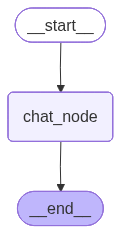

In [56]:
check_pointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=check_pointer)
chatbot

In [57]:
# initial_state={
#     'messages':[
#         HumanMessage(content='what is the capital of US')
#     ]
# }

# output = chatbot.invoke(initial_state)

In [58]:
# print(output['messages'][-1].content)

In [ ]:
# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite"
# )

# response = llm.invoke("What is the capital of India?")

# print(response.content)

The capital of India is **New Delhi**.


In [64]:
thread_id = '1'
while True:
    user_message = input("Type here:")
    
    print(f"Me : {user_message}")

    if user_message.strip().lower() in ['exit','quit','stop','bye']:
        print("AI : Thanks for chatting with me! Have a great day 👋")
        break

    
    try:
        print('Thinking....')
        config = {
            'configurable':{
                'thread_id':thread_id
            }
        }

        response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]}, config=config)
        print(f"AI : {response['messages'][-1].content}")
    except Exception as e:
        print("Error:", e)
    


Me : hi
Thinking....
AI : 110 is an **even** number.

And hihi back to you! 😄
Me : how many days in a year?
Thinking....
AI : There are **365 days** in a common year.

However, in a **leap year**, there are **366 days**. Leap years occur every four years, with the exception of years divisible by 100 but not by 400.
Me : bye
AI : Thanks for chatting with me! Have a great day 👋


In [65]:
chatbot.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='hi, my name is sai', additional_kwargs={}, response_metadata={}, id='dd71d490-d5cf-4a8c-b89f-72d1cd0c2fc2'), AIMessage(content='Hi Sai, nice to meet you!\n\nHow can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ee3c7-479a-7182-8279-0b3c09428c56-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 335, 'total_tokens': 342, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 319}}), HumanMessage(content='what is my name ?', additional_kwargs={}, response_metadata={}, id='c15b942e-9c7d-4319-a534-a8438e2144ee'), AIMessage(content='Your name is Sai.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ee3

In [67]:
snapshot = chatbot.get_state(config)

for msg in snapshot.values["messages"]:
    role = msg.__class__.__name__.replace("Message", "")
    print(f"\n{role}: {msg.content}")


Human: hi, my name is sai

AI: Hi Sai, nice to meet you!

How can I help you today?

Human: what is my name ?

AI: Your name is Sai.

Human: add 100 and 10

AI: 100 + 10 = 110

Human: and multiply by 2

AI: 110 * 2 = 220

Human: and divide by 2

AI: 220 / 2 = 110

Human: is that even or odd?

Human: hi

Human: hi

AI: 110 is an **even** number.

And hihi back to you! 😄

Human: how many days in a year?

AI: There are **365 days** in a common year.

However, in a **leap year**, there are **366 days**. Leap years occur every four years, with the exception of years divisible by 100 but not by 400.


In [66]:
import google.generativeai as genai

genai.configure(api_key=os.getenv('GOOGLE_API_KEY'))

for model in genai.list_models():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr